This notebook discusses NRLEE nucleosynthesis via Jupyter technology.  As you read through the text, you can execute the code blocks.  You can change input (for example, choose different axis ranges or scaling or select different species to show in the plots).  You can right-click or control-click on figures to save them.  If your current version gets corrupted, don't worry.  Simply quit and download a new copy from GitHub, or start up a new version on Google Colab.

## Table of Contents:

[Introduction](#introduction)<br/>
[Preliminaries](#preliminaries)<br/>
[Model Selection](#model)<br/>
[Full Model](#full)<br/>

<a id='introduction'></a>
# Introduction

This notebook allows users to explore NRLEE (Neutron-Rich, Low-Entropy matter Ejector) nucleosythesis in simple models.  NRLEEs are possibly the explosions of dense, white dwarf stars, and this [figure](https://osf.io/zerch) shows the anatomy of a plausible NRLEE model immediately after the explosion.

The initial composition of the white dwarf star was set by pre-explosion helium burning, in which case the composition of the star was dominated by the ashes of that burning stage, namely $^{12}$C and $^{16}$O, or, if the initial star was sufficiently massive, by pre-explosion carbon burning, in which case the composition was dominated by $^{16}$, $^{20}$Ne, and $^{24}$Mg.  In either case, the initial composition of the white dwarf was not neutron rich--it had roughly equal numbers of neutrons and protons.  In the densest part of the star, electron-capture reactions during the explosion allowed the matter to become neutron rich.  The low entropy of the matter (few photons per nucleon) then favored production of light, neutron-rich, iron-group isotopes during the explosive burning.  Outside the densest regions of the star, electron-capture reactions were slower during the explosion.  The matter did not become neutron rich and the explosive burning produced less neutron-rich iron-group species than in the denser region and lower-mass species like $^{28}$Si.  At still lower densities, the peak temperatures reached during the explosion were lower, and the material experienced varying degrees of oxygen burning.  In this region, some $\gamma$ processing also occurred.  Finally, in the outermost regions, peak temperatures were still lower and, if the star had initial carbon, this region experience varying degress of explosive carbon burning.  Any initial $^{22}$Ne in this region allowed a burst of neutrons to occur, which produced interesting isotopes like $^{96}$Zr.

The co-production of isotopes showing key isotopic anomalies in primitive meteoritic samples suggests dust that condensed in NRLEE outflows may have been important contributors to the Solar System's inventory of stellar condensate building blocks.  This makes NRLEE nucleosynthesis interesting for cosmochemistry as well as for astrophysics.  This notebook is intended to illustrate NRLEE nucleosynthesis by presenting in a interactive format the results of models computed with the Webnucleo [NRLEE-Nucleosynthesis](https://github.com/mbradle/NRLEE-Nucleosynthesis) project.  Each model comprises a set of single-zone network calculations with varying initial temperature and density.  The initial composition for the models was computed with the Webnucleo [mainline-nucleosynthesis](https://github.com/mbradle/mainline-nucleosynthesis) and [simple_s_process](https://github.com/mbradle/simple_s_process) projects.  The notebook dowloads data for a given NRLEE model from [OSF](https://osf.io/hz7uv/).  It then uses [wnutils](https://wnutils.readthedocs.io) routines to read, plot, and animate the data.  Users can download selected data as a text file for their own purposes.

<a id='preliminaries'></a>
# Preliminaries

First perform some preliminary operations to set up the notebook.  Once these operations are completed, they need not be repeated when other input is changed.

<a id='General'></a>
## General

Here we import packages and download data.  First, import the necessary packages and download the necessary data.

In [1]:
import sys
!{sys.executable} -m pip install --quiet wnutils

The next step is to import the packages to check for and retrieve the data:

In [2]:
import os, io, requests
from lxml import etree

This notebook uses [wnutils](https://wnutils.readthedocs.io) to analyze the nucleosyntheis [XML](https://www.w3.org/TR/REC-xml/) output, so the next code block imports that package.  It also imports the matplotlib and numpy packages.

In [3]:
import wnutils.xml as wx
import wnutils.multi_xml as mx
import matplotlib.pyplot as plt
import numpy as np

<a id='polytrope'></a>
## Polytrope

This section sets up the packages, data, and routines for computing the polytrope solutions for white dwarf stars.  First, import the necessary packages.

In [4]:
from scipy.integrate import odeint
from scipy.optimize import root_scalar

Now we define the Lane-Emden equation as two first order derivatives.  Also add a tiny amount to the denominator of one term to avoid overflows and take the absolute value of $\theta$ in taking powers because this is a problem for some n values.  In our treatment, where we are only considering physically relevant solutions (with $\theta \geq 0$), this last point is only an issue near the root when we are root finding.  Near the root, the $\theta^n$ term contributes negligibly to the derivative.

In [5]:
def lane_emden(y, x, n):
    theta, dtheta = y
    dydx = [dtheta, -2. * dtheta / (x + 1.e-300) - np.power(np.abs(theta), n)]
    return dydx

In [6]:
def f(x, phi_0, n):
    assert(n > 0 and n < 5)
    y0 = [1., 0.]
    xsol = np.linspace(0, x, 2)
    sol = odeint(lane_emden, y0, xsol, args=(n,))
    result = sol[sol.shape[0]-1, 0] - phi_0
    if abs(result) < 1.e-6:
        result = 0
    return result

In [7]:
def get_mass_coordinates(M, n, rhos):
    rho_c = rhos[0]
    Ms = []
    dM = []

    r_sol = root_scalar(f, args=(0, n), x0 = 0, x1 = 1)
    xsi_1 = r_sol.root
    x = np.linspace(0, xsi_1, 101)
    msol = odeint(lane_emden, [1., 0.], x, args=(n,))
    dphi_1 = msol[msol.shape[0]-1, 1]

    for r in rhos:
        phi_0 = (r / rho_c)**(1./n)
        r_sol = root_scalar(f, args=(phi_0, n), x0 = 0, x1 = 1)
        xsi = r_sol.root
        x = np.linspace(0, xsi, 101)
        msol = odeint(lane_emden, [1., 0.], x, args=(n,))
        dphi = msol[msol.shape[0]-1, 1]
        Ms.append(M * xsi**2 * dphi / (xsi_1**2 * dphi_1))
    
    Ms[0] = 0  # Reset to avoid slightly non-zero value due to numerical inaccuracies.

    for i in range(len(Ms)-1):
        dM.append(Ms[i+1] - Ms[i])
    
    dM.append(M - Ms[len(Ms)-1])
    
    return (Ms, dM)

<a id='model'></a>
# Model Selection

In [8]:
folder = 'out_metals_t9p_10'
xmls = []

for subdir, dirs, files in os.walk(folder):
    for file in files:
        xmls.append(wx.Xml(os.path.join(subdir, file)))

<a id='full'></a>

# The Full Model

The exploding white dwarf star was simulated by taking an initial composition from an s-process calculation and considering that composition at a variety of initial densities.  The matter was imagined to be heated to an initial temperature that was a function of the initial density and then allowed to expand and cool on an exponential timescale.  The first section in what follows shows the results from these calculations.  The second section applies the Lane-Emden equations to create a simple model of a white dwarf star with the resulting nucleosynthesis yields.

Begin by reading the data for the full model.

## Initial density

Retrieve key properties from a chosen density range from the full XML input.  The default is all zones, but the commented out line shows how to select a more limited set that would ultimately represent a white dwarf star with a lower central density.

In [9]:
nucs_dict = {}
for key, value in xmls[0].get_nuclide_data().items():
    nucs_dict[(value['z'], value['a'])] = key

In [10]:
props_list = ['rho_0', 't9_0', 'scaled metallicity']

In [11]:
def get_zone_contributions(Ms):
    fm = np.zeros(len(Ms))
    for i in range(len(Ms)):
        if Ms[i] < 1:
            fm[i] = 0.1
        else:
            fm[i] = 1
    return fm

In [12]:
def get_mass_fractions_and_ejected_mass(xml, nucs_dict, Ms, dM):
    
    y = xml.get_all_abundances_in_zones()
    M_ej = 0
    
    fm = get_zone_contributions(Ms)

    for i, ff in enumerate(fm):
        y[i, :, :] *= ff * dM[i]
        M_ej += ff * dM[i]
    
    ym = np.sum(y, axis = 0)

    x_dict = {}
    for z in range(ym.shape[0]):
        for n in range(ym.shape[1]):
            a = z + n
            key = (z, a)
            if key in nucs_dict:
                x_dict[(nucs_dict[(z, a)], z, a)] = ym[z, n] * a / M_ej
    
    return (x_dict, M_ej)               

## Convert to a white dwarf model

Convert the initial densities to a white-dwarf star model by applying a polytropic solution (a solution to the Lane-Emden equation).  Choose the total mass in solar masses (1.4 Solar masses is the typical Chandrasekhar limit, which is the theoretical maximum limit on a stable white dwarf star mass for matter with equal numbers of neutrons and protons) and the polytropic index, which can range $0 < n < 5$.  The smaller $n$ is, the more uniform the density is in the model.  The central density is determined from the XML input.  We store the densities and flip them (to go from high to low) to align them with interior mass coordinates later.  If you would like to change the central density of the white dwarf model, change the *zone_xpath* above.

In [13]:
M = 1.4
n = 3

Compute the interior mass coordinates based on the chosen index and total mass.  The central density is determined from the XML input.  We store the densities and flip them to align them with the interior mass.  Also compute shell thicknesses.

## Create a yield file

In [14]:
zones = {}
for xml in xmls:
    props = xml.get_properties_as_floats(props_list)

    rhos = np.flip(props['rho_0'])

    Ms, dM = get_mass_coordinates(M, n, rhos)
    
    x_dict, M_ej = get_mass_fractions_and_ejected_mass(xml, nucs_dict, Ms, dM)
    metallicity = str(props['scaled metallicity'][0])
    zone_label = ("NRLEE", metallicity)
    properties = {'ejected mass': str(M_ej)}
    for prop, value in props.items():
        properties[prop] = str(value[0])
    zones[zone_label] = {'properties': properties, 'mass fractions': x_dict}
    
zones = dict(sorted(zones.items(), key=lambda key: key[0][1]))

Write out the XML file for the yields.  Change the name of the output file by changing *out_file*.

In [15]:
out_file = 'nrlee_yields.xml'

new_xml = wx.New_Xml(xml_type='libnucnet_input')
new_xml.set_nuclide_data(xmls[0].get_nuclide_data())
new_xml.set_zone_data(zones)

new_xml.write(out_file)

# Check the output.

Read in the yields.

In [16]:
new = wx.Xml(out_file)

Plot the chosen species.

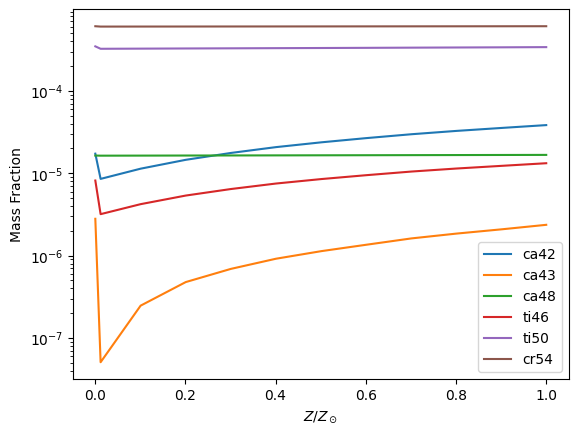

In [21]:
species = ['ca42', 'ca43', 'ca48', 'ti46', 'ti50', 'cr54']
new.plot_mass_fractions_vs_property('scaled metallicity', species, xlabel='$Z / Z_\\odot$', yscale = 'log')